In [18]:
from qiskit import *
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#   ────────────────────────────── Configuration ───────────────────────────────

#%matplotlib widget

# Dataset

N          = 2000    # Number of generated points

N_DIM      = 3       # Feature space dimension (sphere in R^N_DIM)

TEST_SIZE  = 0.5     # Fraction used for test set

SEED       = 1       # Random seed (data split & optimizer init)



# Model

RC         = 3       # Number of circuit layers (re-uploading rounds)



# Derived (do not edit manually)

N_GATES_PER_LAYER   = int(np.ceil(N_DIM / 3))  # each U packs up to 3 features

N_PARAMS_PER_LAYER  = N_GATES_PER_LAYER * 3    # (theta + omega) per layer



# Optimization

MAXITER    = 300     # COBYLA max iterations



# Simulation

USE_NOISE  = True    # True -> noisy AerSimulator | False -> Statevector

NOISE_RATE = 0.005   # Depolarizing error rate per gate

SHOTS      = 1024    # Number of shots



# AdaBoost

N_ESTIMATORS = 5     # Number of weak QNN classifiers in the ensemble



# Data generation

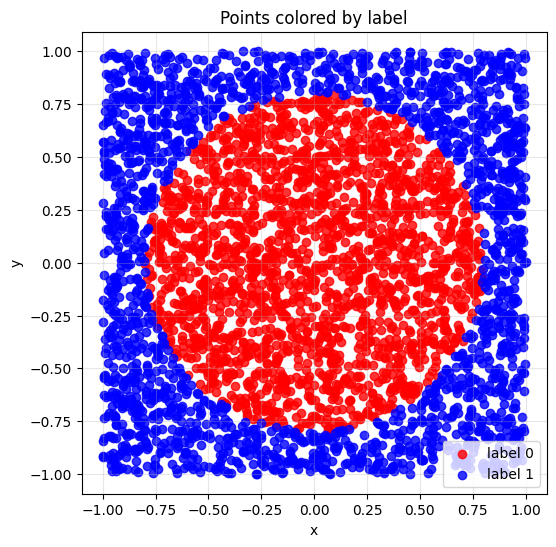

points in label 0: 2010
points in label 1: 1990


In [ ]:
rng = np.random.default_rng(SEED)



# Sample uniformly in [-1, 1]^N_DIM

points = rng.uniform(-1, 1, size=(N, N_DIM))

radius = np.sqrt(N_DIM / 3)

labels = (np.sum(points**2, axis=1) >= radius**2).astype(int)



arr = np.array(points)

lbl = np.array(labels)



if N_DIM == 2:

    plt.figure(figsize=(6, 6))

    plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)

    plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)

    circle = plt.Circle((0, 0), radius, color="black", fill=False, linestyle="--", linewidth=2)

    plt.gca().add_patch(circle)

    plt.xlabel("x0")

    plt.ylabel("x1")

    plt.title("Points colored by label (2D projection)")

    plt.axis("equal")

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.show()

else:

    print(f"Data generated in {N_DIM}D. Plotting skipped (only shown when N_DIM == 2).")



print("points in label 0:", np.sum(lbl == 0))

print("points in label 1:", np.sum(lbl == 1))



In [21]:
rng = np.random.default_rng(SEED)

indices   = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - TEST_SIZE))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


X_train: (2000, 2) y_train: (2000,)
X_test : (2000, 2) y_test : (2000,)


In [ ]:
def apply_reupload_layer(qc, theta_row, omega_row, x, qubit=0):

    """Apply a layer of parameterized U gates that re-upload features in groups of 3."""

    for g in range(N_GATES_PER_LAYER):

        base = 3 * g

        params = []

        for i in range(3):

            idx = base + i

            val = theta_row[idx]

            if idx < N_DIM:

                val += omega_row[idx] * x[idx]

            params.append(val)

        qc.u(params[0], params[1], params[2], qubit)


In [ ]:
def create_circuit(x, theta, omega, measure=True):

    qc = QuantumCircuit(1)

    for i in range(RC):

        qc.h(0)

        apply_reupload_layer(qc, theta[i], omega[i], x, qubit=0)

    if measure:

        qc.measure_all()

    return qc



# quick illustration circuit

theta = np.ones((RC, N_PARAMS_PER_LAYER))

omega = np.ones((RC, N_PARAMS_PER_LAYER))

qc = create_circuit(X_train[0], theta, omega)

qc.draw('mpl')



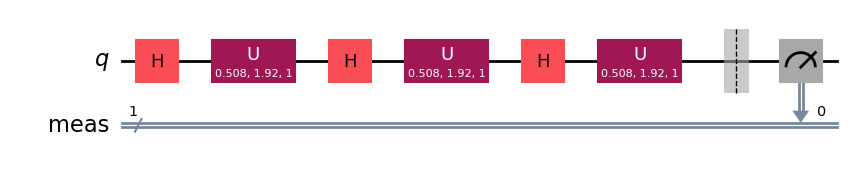

In [24]:
theta = [[1, 1, 1] for _ in range(RC)]
omega = [[1, 1, 1] for _ in range(RC)]
qc = create_circuit(X_train[0], theta, omega)
qc.draw('mpl')


In [25]:
def build_simulator():
    if USE_NOISE:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(NOISE_RATE, 1), ['u'])
        return AerSimulator(noise_model=nm)
    return StatevectorSimulator()

sv_sim = build_simulator()

def get_probs_batch(circuits):
    """
    Returns a list of (p0, p1) for each circuit.
    Noiseless: exact statevector amplitudes.
    Noisy:     shot-based counts normalised by SHOTS.
    """
    if USE_NOISE:
        meas = [c.copy() for c in circuits]
        for c in meas:
            c.measure_all()
        compiled = transpile(meas, sv_sim)
        results  = sv_sim.run(compiled, shots=SHOTS).result()
        return [
            (results.get_counts(i).get('0', 0) / SHOTS,
             results.get_counts(i).get('1', 0) / SHOTS)
            for i in range(len(meas))
        ]
    else:
        compiled = transpile(circuits, sv_sim)
        results  = sv_sim.run(compiled).result()
        return [
            (float(np.abs(results.get_statevector(i).data[0])**2),
             float(np.abs(results.get_statevector(i).data[1])**2))
            for i in range(len(circuits))
        ]


In [ ]:
def cost_function_weighted(params, X_train, y_train):

    theta  = params[:N_PARAMS_PER_LAYER * RC].reshape(RC, N_PARAMS_PER_LAYER)

    omega  = params[N_PARAMS_PER_LAYER * RC:2 * N_PARAMS_PER_LAYER * RC].reshape(RC, N_PARAMS_PER_LAYER)

    alphas = params[2 * N_PARAMS_PER_LAYER * RC:]   # alpha_0, alpha_1



    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]

    probs    = get_probs_batch(circuits)



    total_cost = 0.0

    for i, y_target in enumerate(y_train):

        f0, f1     = probs[i]

        y_expected = [1.0, 0.0] if y_target == 0 else [0.0, 1.0]

        total_cost += (alphas[0] * f0 - y_expected[0])**2

        total_cost += (alphas[1] * f1 - y_expected[1])**2



    return 0.5 * (total_cost / len(y_train))



In [ ]:
def unpack_params(params):

    theta  = params[:N_PARAMS_PER_LAYER * RC].reshape(RC, N_PARAMS_PER_LAYER)

    omega  = params[N_PARAMS_PER_LAYER * RC:2 * N_PARAMS_PER_LAYER * RC].reshape(RC, N_PARAMS_PER_LAYER)

    alphas = params[2 * N_PARAMS_PER_LAYER * RC:]

    return theta, omega, alphas



def optimize_parameters(X_train, y_train):

    rng  = np.random.default_rng(SEED)

    init = rng.uniform(-np.pi, np.pi, size=2 * N_PARAMS_PER_LAYER * RC + 2)



    cache = {"cost": None}

    cost_history = []

    step = {"k": 0}



    def objective(params):

        cost = cost_function_weighted(params, X_train, y_train)

        cache["cost"] = cost

        return cost



    def cb(xk):

        step["k"] += 1

        cost_history.append(cache["cost"])

        print(f"Step {step['k']:03d} | cost = {cache['cost']:.6f}")



    res = minimize(objective, init, method="COBYLA",

                   callback=cb, options={"maxiter": MAXITER})



    theta_opt, omega_opt, _ = unpack_params(res.x)

    print(f"Final cost = {res.fun:.6f}")

    return theta_opt, omega_opt, res, cost_history



In [28]:
def predict_batch(X, theta, omega):
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    probs    = get_probs_batch(circuits)
    return np.array([0 if p0 >= 0.5 else 1 for p0, _ in probs])

def evaluate_metrics(X, y, theta, omega, positive_label=1):
    y_pred    = predict_batch(X, theta, omega)
    tp        = np.sum((y_pred == positive_label) & (y == positive_label))
    fp        = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy  = np.mean(y_pred == y)
    return precision, accuracy, y_pred

mode_label = "Noisy" if USE_NOISE else "Noiseless"
sv_sim = build_simulator()

theta_opt, omega_opt, res, cost_history = optimize_parameters(X_train, y_train)
precision_test, accuracy_test, y_pred = evaluate_metrics(X_test, y_test, theta_opt, omega_opt)

print(f"[{mode_label}] Final train cost:", res.fun)
print(f"[{mode_label}] Test precision:", precision_test)
print(f"[{mode_label}] Test accuracy:", accuracy_test)


Step 001 | cost = 2.520436
Step 002 | cost = 2.603354
Step 003 | cost = 2.280839
Step 004 | cost = 2.125002
Step 005 | cost = 2.292772
Step 006 | cost = 2.105504
Step 007 | cost = 2.273518
Step 008 | cost = 2.317538
Step 009 | cost = 2.105506
Step 010 | cost = 2.509824
Step 011 | cost = 2.063910
Step 012 | cost = 2.194416
Step 013 | cost = 2.064324
Step 014 | cost = 2.029759
Step 015 | cost = 2.038895
Step 016 | cost = 2.030481
Step 017 | cost = 2.091651
Step 018 | cost = 2.031087
Step 019 | cost = 2.031217
Step 020 | cost = 1.506003
Step 021 | cost = 0.905716
Step 022 | cost = 0.507624
Step 023 | cost = 0.412661
Step 024 | cost = 0.411832
Step 025 | cost = 0.364340
Step 026 | cost = 0.377784
Step 027 | cost = 0.335883
Step 028 | cost = 0.407987
Step 029 | cost = 0.443415
Step 030 | cost = 0.373835
Step 031 | cost = 0.380406
Step 032 | cost = 0.336230
Step 033 | cost = 0.336524
Step 034 | cost = 0.336090
Step 035 | cost = 0.338683
Step 036 | cost = 0.334672
Step 037 | cost = 0.325340
S

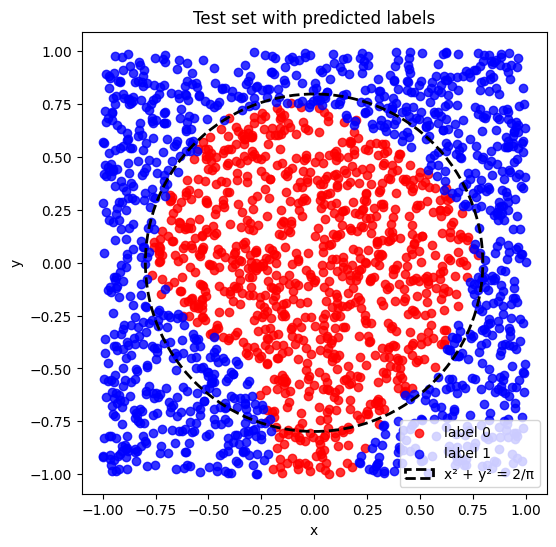

In [ ]:
plt.figure(figsize=(6, 6))

if N_DIM == 2:

    plt.scatter(X_test[y_pred == 0][:, 0], X_test[y_pred == 0][:, 1], c="red", label="label 0", alpha=0.8)

    plt.scatter(X_test[y_pred == 1][:, 0], X_test[y_pred == 1][:, 1], c="blue", label="label 1", alpha=0.8)

    circle = plt.Circle((0, 0), radius, color="black", fill=False, linestyle="--", linewidth=2, label="||x||^2 = r^2")

    plt.gca().add_patch(circle)

    plt.axis("equal")

    plt.xlabel("x0")

    plt.ylabel("x1")

    plt.title("Test set with predicted labels (2D)")

    plt.legend()

else:

    plt.title("Plot skipped (only available when N_DIM == 2)")

plt.show()


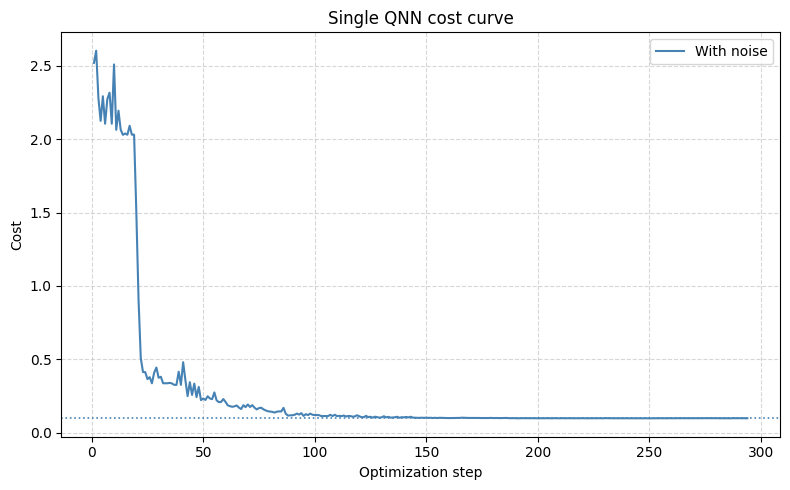

In [30]:
plt.figure(figsize=(8, 5))
ax1 = plt.subplot(1, 1, 1)

ax1.plot(
    range(1, len(cost_history) + 1),
    cost_history,
    color="steelblue" if USE_NOISE else "darkorange",
    linewidth=1.5,
    label="With noise" if USE_NOISE else "Without noise"
)
ax1.axhline(
    res.fun,
    color="steelblue" if USE_NOISE else "darkorange",
    linestyle=":",
    linewidth=1.2
)

ax1.set_xlabel("Optimization step")
ax1.set_ylabel("Cost")
ax1.set_title("Single QNN cost curve")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

plt.tight_layout()
plt.show()


# AdaBoost


In [ ]:
def cost_fn_weighted_samples(params, X, y, sample_weights):

    theta = params[:N_PARAMS_PER_LAYER * RC].reshape(RC, N_PARAMS_PER_LAYER)

    omega = params[N_PARAMS_PER_LAYER * RC:2 * N_PARAMS_PER_LAYER * RC].reshape(RC, N_PARAMS_PER_LAYER)



    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]

    probs = get_probs_batch(circuits)



    total = 0.0

    for i, y_t in enumerate(y):

        p0, p1 = probs[i]

        e0, e1 = (1.0, 0.0) if y_t == 0 else (0.0, 1.0)

        total += sample_weights[i] * ((p0 - e0) ** 2 + (p1 - e1) ** 2)



    return 0.5 * total / np.sum(sample_weights)





def optimize_weak_learner(X, y, sample_weights, seed):

    rng = np.random.default_rng(seed)

    init = rng.uniform(-np.pi, np.pi, size=2 * N_PARAMS_PER_LAYER * RC)



    res = minimize(

        cost_fn_weighted_samples,

        init,

        args=(X, y, sample_weights),

        method="COBYLA",

        options={"maxiter": MAXITER},

    )



    theta = res.x[:N_PARAMS_PER_LAYER * RC].reshape(RC, N_PARAMS_PER_LAYER)

    omega = res.x[N_PARAMS_PER_LAYER * RC:].reshape(RC, N_PARAMS_PER_LAYER)

    return theta, omega, res.fun



In [32]:
mode_label = "Noisy" if USE_NOISE else "Noiseless"

print(f"=== AdaBoost ({mode_label.lower()}) ===")
estimators_boost = train_adaboost(X_train, y_train, n_estimators=N_ESTIMATORS)

metrics_boost = evaluate_adaboost(X_test, y_test, estimators_boost)
precision_boost = metrics_boost["precision"]
accuracy_boost = metrics_boost["accuracy"]
y_pred_boost = metrics_boost["y_pred"]

print("\nSingle QNN")
print(f"precision={precision_test:.4f} | accuracy={accuracy_test:.4f}")

print("\nAdaBoost")
print(f"precision={precision_boost:.4f} | recall={metrics_boost['recall']:.4f} | accuracy={accuracy_boost:.4f}")
print(
    f"TP={metrics_boost['tp']} FP={metrics_boost['fp']} "
    f"FN={metrics_boost['fn']} TN={metrics_boost['tn']}"
)

=== AdaBoost (noisy) ===
round 01 | cost=0.1047 eps=0.0935 alpha=1.1358
round 02 | cost=0.1319 eps=0.1434 alpha=0.8936
round 03 | cost=0.2195 eps=0.3600 alpha=0.2877
round 04 | cost=0.1563 eps=0.1945 alpha=0.7106
round 05 | cost=0.1731 eps=0.2142 alpha=0.6498

Single QNN
precision=0.8415 | accuracy=0.8875

AdaBoost
precision=0.8943 | recall=0.9979 | accuracy=0.9415
TP=973 FP=115 FN=2 TN=910


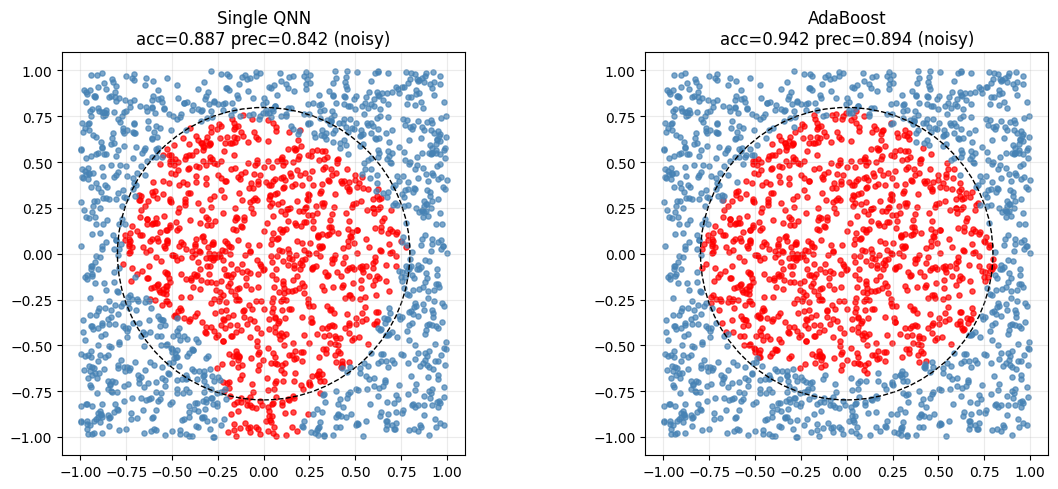

In [ ]:
mode_label = "Noisy" if USE_NOISE else "Noiseless"



fig, axes = plt.subplots(1, 2, figsize=(12, 5))



plots = [

    (y_pred, f"Single QNN\nacc={accuracy_test:.3f} prec={precision_test:.3f}"),

    (y_pred_boost, f"AdaBoost\nacc={accuracy_boost:.3f} prec={precision_boost:.3f}"),

]



for ax, (pred, title) in zip(axes, plots):

    if N_DIM == 2:

        ax.scatter(X_test[pred == 0][:, 0], X_test[pred == 0][:, 1], c="red", s=14, alpha=0.7)

        ax.scatter(X_test[pred == 1][:, 0], X_test[pred == 1][:, 1], c="steelblue", s=14, alpha=0.7)

        ax.add_patch(plt.Circle((0, 0), radius, color="black", fill=False, linestyle="--"))

        ax.set_xlim(-1.1, 1.1)

        ax.set_ylim(-1.1, 1.1)

        ax.set_aspect("equal")

    else:

        ax.text(0.5, 0.5, "Plot only for N_DIM=2", ha="center", va="center", transform=ax.transAxes)

    ax.grid(True, alpha=0.25)

    ax.set_title(f"{title} ({mode_label.lower()})")



plt.tight_layout()

plt.show()


# Confusion matrices
Visual comparison of classification errors for Single QNN and AdaBoost on the test set.

C:\Users\Gnomp\AppData\Local\Temp\ipykernel_23676\3676949266.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


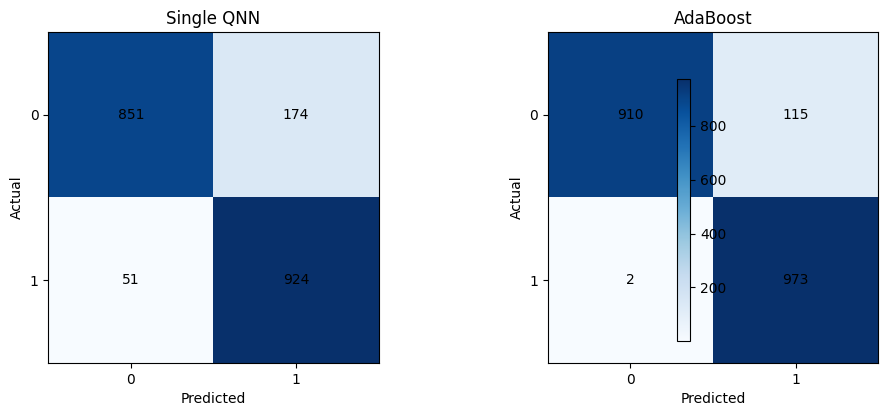

Single QNN confusion matrix [[TN, FP], [FN, TP]]:
[[851 174]
 [ 51 924]]

AdaBoost confusion matrix [[TN, FP], [FN, TP]]:
[[910 115]
 [  2 973]]


In [34]:
def confusion_matrix_2x2(y_true, y_pred, positive_label=1):
    tp = np.sum((y_pred == positive_label) & (y_true == positive_label))
    fp = np.sum((y_pred == positive_label) & (y_true != positive_label))
    fn = np.sum((y_pred != positive_label) & (y_true == positive_label))
    tn = np.sum((y_pred != positive_label) & (y_true != positive_label))
    return np.array([[tn, fp], [fn, tp]], dtype=int)

cm_single = confusion_matrix_2x2(y_test, y_pred, positive_label=1)
cm_boost = confusion_matrix_2x2(y_test, y_pred_boost, positive_label=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cms = [
    (cm_single, "Single QNN"),
    (cm_boost, "AdaBoost"),
]

for ax, (cm, title) in zip(axes, cms):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([0, 1])
    ax.set_yticks([0, 1])
    ax.set_yticklabels([0, 1])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
plt.tight_layout()
plt.show()

print("Single QNN confusion matrix [[TN, FP], [FN, TP]]:")
print(cm_single)
print("\nAdaBoost confusion matrix [[TN, FP], [FN, TP]]:")
print(cm_boost)